In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings

In [29]:
filterwarnings("ignore")

In [30]:
def get_sse(X, labels):
    sse = 0
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        sse += np.sum(cdist(np.expand_dims(c, axis=0), X[labels == l]) ** 2)
    return sse


def get_bss(X, labels):
    cluster_centers = list()
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        cluster_centers.append(c)
    cluster_centers = np.array(cluster_centers)
    _, sizes = np.unique(labels, return_counts=True)
    m = np.mean(X, axis=0)
    bss = np.sum(sizes * cdist(np.expand_dims(m, axis=0), cluster_centers) ** 2)
    return bss


def eval_clustering(X, labels):
    sse = get_sse(X[labels != -1], labels[labels != -1])
    bss = get_bss(X[labels != -1], labels[labels != -1])
    silh = silhouette_score(X[labels != -1], labels[labels != -1])
    return sse, bss, silh

In [31]:
df_event_profile = pd.read_csv("Event_profile_static.csv")

In [32]:
df_event_profile

,sport,event,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,hhi_gold_mean,n_nations_with_gold,n_editions
0,3x3 Basketball,"3x3 Basketball, Men",True,8.000000,8,8.000000,1.0,1.0,1
1,3x3 Basketball,"3x3 Basketball, Women",True,8.000000,8,8.000000,1.0,1.0,1
2,Archery,"Individual, Men",False,32.769231,40,61.461538,1.0,1.0,13
3,Archery,"Individual, Women",False,29.615385,40,54.923077,1.0,1.0,13
4,Archery,"Team, Men",True,14.666667,22,14.666667,1.0,1.0,9
...,...,...,...,...,...,...,...,...,...
452,Wushu,"Sanshou (≤60 kilograms), Women",False,7.000000,7,7.000000,NaN,0.0,1
453,Wushu,"Sanshou (≤70 kilograms), Men",False,7.000000,7,7.000000,NaN,0.0,1
454,Wushu,"Sanshou (≤85 kilograms), Men",False,8.000000,8,8.000000,NaN,0.0,1
455,Wushu,"Taijiquan & Taijijuan, Men",False,8.000000,8,8.000000,NaN,0.0,1


In [33]:
df_event_profile.shape

(457, 9)

In [34]:
df_event_profile = df_event_profile[df_event_profile['n_editions'] >= 5]

In [35]:
df_event_profile

,sport,event,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,hhi_gold_mean,n_nations_with_gold,n_editions
2,Archery,"Individual, Men",False,32.769231,40,61.461538,1.000000,1.000000,13
3,Archery,"Individual, Women",False,29.615385,40,54.923077,1.000000,1.000000,13
4,Archery,"Team, Men",True,14.666667,22,14.666667,1.000000,1.000000,9
6,Archery,"Team, Women",True,13.333333,17,13.333333,1.000000,1.000000,9
7,Artistic Gymnastics,"Balance Beam, Women",False,28.466667,47,86.733333,1.000000,1.000000,15
...,...,...,...,...,...,...,...,...,...
437,Wrestling,"Middleweight, Greco-Roman, Men",False,18.533333,21,18.533333,1.000000,1.000000,15
438,Wrestling,"Super-Heavyweight, Freestyle, Men",False,16.000000,20,16.000000,0.961538,1.076923,13
439,Wrestling,"Super-Heavyweight, Greco-Roman, Men",False,16.000000,20,16.000000,1.000000,1.000000,13
440,Wrestling,"Welterweight, Freestyle, Men",False,20.933333,29,20.933333,1.000000,1.000000,15


In [36]:
df_event_profile.shape

(317, 9)

In [37]:
df_event_profile.columns

Index(['sport', 'event', 'is_team_event', 'n_nations_mean', 'n_nations_max',
       'n_athletes_mean', 'hhi_gold_mean', 'n_nations_with_gold',
       'n_editions'],
      dtype='object')

In [38]:
num_features = ['is_team_event', 'n_nations_mean', 'n_nations_max', 'n_athletes_mean', 'hhi_gold_mean', 'n_nations_with_gold', 'n_editions']

corr = df_event_profile[num_features].corr()

corr

,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,hhi_gold_mean,n_nations_with_gold,n_editions
is_team_event,1.000000,-0.502598,-0.491090,-0.480584,0.032998,-0.026974,-0.083346
n_nations_mean,-0.502598,1.000000,0.967485,0.790891,-0.060922,0.221783,0.229203
n_nations_max,-0.491090,0.967485,1.000000,0.775368,-0.072030,0.220039,0.329606
n_athletes_mean,-0.480584,0.790891,0.775368,1.000000,-0.287288,0.226679,0.288210
hhi_gold_mean,0.032998,-0.060922,-0.072030,-0.287288,1.000000,-0.336221,-0.122745
n_nations_with_gold,-0.026974,0.221783,0.220039,0.226679,-0.336221,1.000000,0.217352
n_editions,-0.083346,0.229203,0.329606,0.288210,-0.122745,0.217352,1.000000


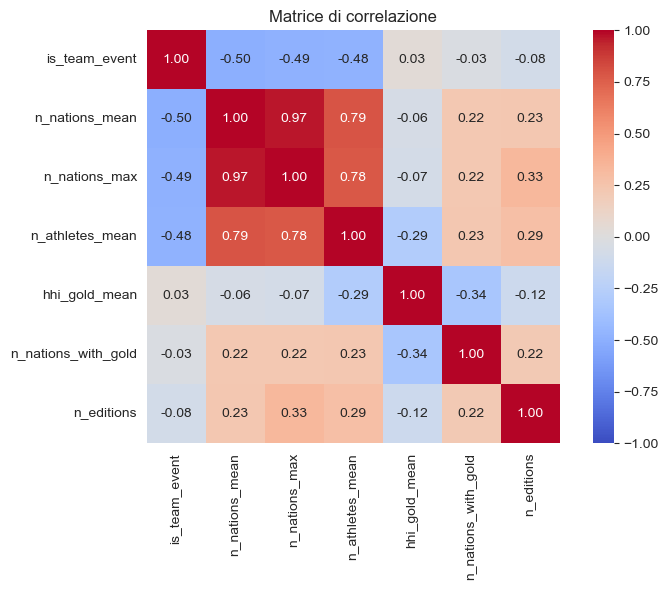

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [40]:
feat_for_clust = ['n_nations_mean', 'n_athletes_mean', 'is_team_event', 'n_nations_with_gold']

In [41]:
print(df_event_profile.isna().sum())

sport                  0
event                  0
is_team_event          0
n_nations_mean         0
n_nations_max          0
n_athletes_mean        0
hhi_gold_mean          2
n_nations_with_gold    0
n_editions             0
dtype: int64


In [42]:
df_event_profile.shape

(317, 9)

In [43]:
events_to_drop = [
    ('Athletics', '1,500 metres Wheelchair, Men'),
    ('Athletics', '800 metres Wheelchair, Women')
]

mask = df_event_profile.apply(
    lambda row: (row['sport'], row['event']) in events_to_drop, axis=1
)

df_event_profile = df_event_profile[~mask]

In [44]:
df_event_profile.shape

(315, 9)

In [45]:
X = df_event_profile[feat_for_clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
kmin = 2
kmax = 20

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

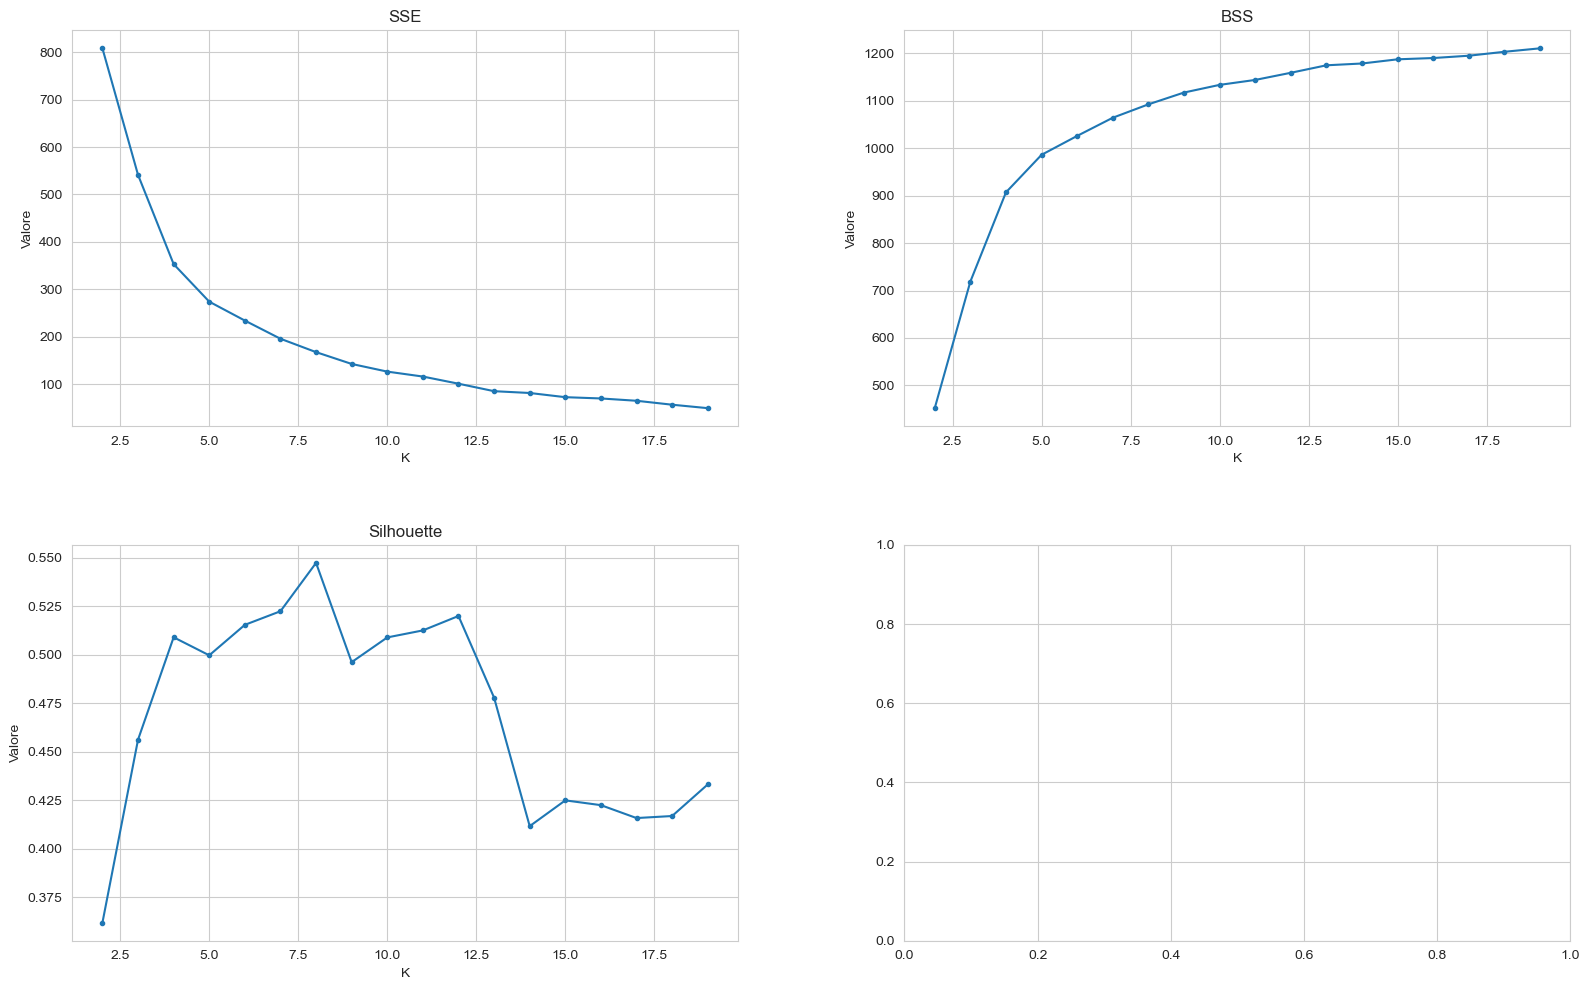

In [47]:
metrics = ["sse", "bss", "silh"]
titles = ["SSE", "BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [48]:
n_clust_5 = KMeans(n_clusters=5,  random_state=42)
n_clust_5.fit(X_scaled)
df_event_profile['cluster_k5'] = n_clust_5.labels_

In [49]:
labels, sizes = np.unique(n_clust_5.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s/len(X)))

Cluster 0: 109 (0.35)
Cluster 1: 77 (0.24)
Cluster 2: 89 (0.28)
Cluster 3: 17 (0.05)
Cluster 4: 23 (0.07)


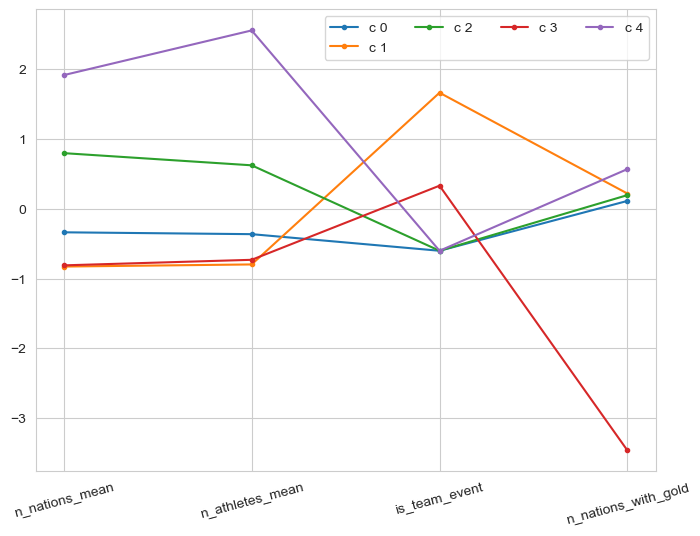

In [50]:
plt.figure(figsize=(8, 6))
for c in np.unique(n_clust_5.labels_):
    plt.plot(feat_for_clust, n_clust_5.cluster_centers_[c], marker='.', label='c %s' % c)

plt.xticks(rotation=15)
plt.legend(ncol=4)
plt.grid(True)
plt.show()

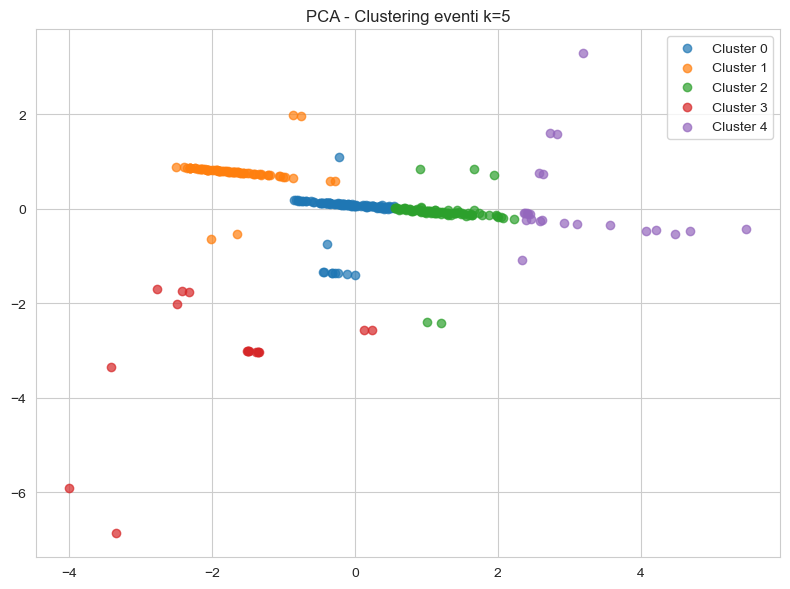

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))

for c in sorted(df_event_profile['cluster_k5'].unique()):
    mask = df_event_profile['cluster_k5'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7)

ax.set_title('PCA - Clustering eventi k=5')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [52]:
for k in sorted(df_event_profile['cluster_k5'].unique()):
    sports = df_event_profile[df_event_profile['cluster_k5'] == k]['event'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['10,000 metres, Women', 'Decathlon, Men', 'Discus Throw, Men', 'Discus Throw, Women', 'Hammer Throw, Men', 'Heptathlon, Women', 'High Jump, Women', 'Javelin Throw, Men', 'Javelin Throw, Women', 'Pentathlon, Women', 'Pole Vault, Men', 'Pole Vault, Women', 'Shot Put, Men', 'Shot Put, Women', 'Heavyweight, Men', 'Light-Heavyweight, Men', 'Middleweight, Men', 'Super-Heavyweight, Men', 'Canadian Singles, Slalom, Men', 'Kayak Singles, Slalom, Men', 'Kayak Singles, Slalom, Women', 'Canadian Singles, 1,000 metres, Men', 'Canadian Singles, 500 metres, Men', 'Kayak Singles, 1,000 metres, Men', 'Kayak Singles, 500 metres, Men', 'Kayak Singles, 500 metres, Women', 'Cross-Country, Women', 'Individual Time Trial, Women', '1,000 metres Time Trial, Men', 'Individual Pursuit, 4,000 metres, Men', 'Individual Pursuit, Women', 'Keirin, Men', 'Sprint, Men', 'Sprint, Women', 'Platform, Men', 'Platform, Women', 'Springboard, Men', 'Springboard, Women', 'Individual, Open', 'Foil, Individual, Wome


Cluster 1 — Eventi di squadra

Cluster nettissimo e separato nel PCA. is_team_event alto, tanti atleti.


Cluster 2 — Eventi individuali globali di media diffusione

Tante nazioni partecipanti, pochi atleti per evento, quasi nessun evento di squadra. Il cluster più grande.


Cluster 0 — Eventi individuali di nicchia

Poche nazioni, pochi atleti, pochissime nazioni con ori. Lotta Greco-Romana, Canoa singolo, Ciclismo su pista, Tuffi, Scherma individuale femminile, Pesistica femminile.


Cluster 4 — I grandi eventi globali

Tante nazioni, pochi atleti, poche nazioni con ori. Gli eventi più seguiti e iconici.


Cluster 3 — Sport di nicchia con poche nazioni

Baseball, Badminton, Taekwondo per categorie: pochissime nazioni partecipanti e pochissime nazioni con ori.

Analisi temporale

In [53]:
df_event_year = pd.read_csv("Event_features_by_year.csv")

df_event_year = df_event_year.merge(
    df_event_profile[['sport', 'event', 'cluster_k5']],
    on=['sport', 'event'],
    how='left'
)

df_event_year = df_event_year.dropna(subset=['cluster_k5'])
df_event_year['cluster_k5'] = df_event_year['cluster_k5'].astype(int)

In [54]:
df_event_year

,sport,event,year,n_nations,n_athletes,is_team_event,hhi_gold,n_nations_with_gold,cluster_k5
2,Archery,"Individual, Men",1972,24,55,False,1.0,1,2
3,Archery,"Individual, Men",1976,23,37,False,1.0,1,2
4,Archery,"Individual, Men",1980,25,38,False,1.0,1,2
5,Archery,"Individual, Men",1984,31,62,False,1.0,1,2
6,Archery,"Individual, Men",1988,34,84,False,1.0,1,2
...,...,...,...,...,...,...,...,...,...
3857,Wrestling,"Welterweight, Greco-Roman, Men",2004,20,20,False,1.0,1,0
3858,Wrestling,"Welterweight, Greco-Roman, Men",2008,20,20,False,1.0,1,0
3859,Wrestling,"Welterweight, Greco-Roman, Men",2012,19,19,False,1.0,1,0
3860,Wrestling,"Welterweight, Greco-Roman, Men",2016,18,18,False,1.0,1,0


In [55]:
trend_k5 = df_event_year.groupby(['cluster_k5', 'year'])[['n_nations', 'n_nations_with_gold', 'n_athletes']].mean().reset_index()

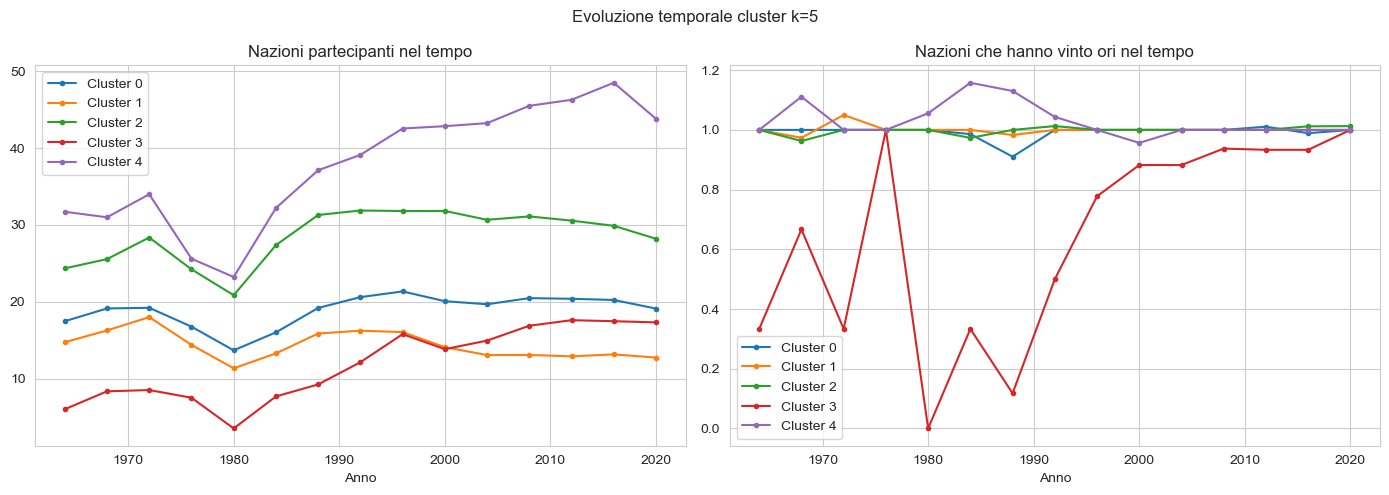

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for c in sorted(trend_k5['cluster_k5'].unique()):
    subset = trend_k5[trend_k5['cluster_k5'] == c]
    axes[0].plot(subset['year'], subset['n_nations'], marker='.', label=f'Cluster {c}')
    axes[1].plot(subset['year'], subset['n_nations_with_gold'], marker='.', label=f'Cluster {c}')

axes[0].set_title('Nazioni partecipanti nel tempo')
axes[0].set_xlabel('Anno')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Nazioni che hanno vinto ori nel tempo')
axes[1].set_xlabel('Anno')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Evoluzione temporale cluster k=5')
plt.tight_layout()
plt.show()

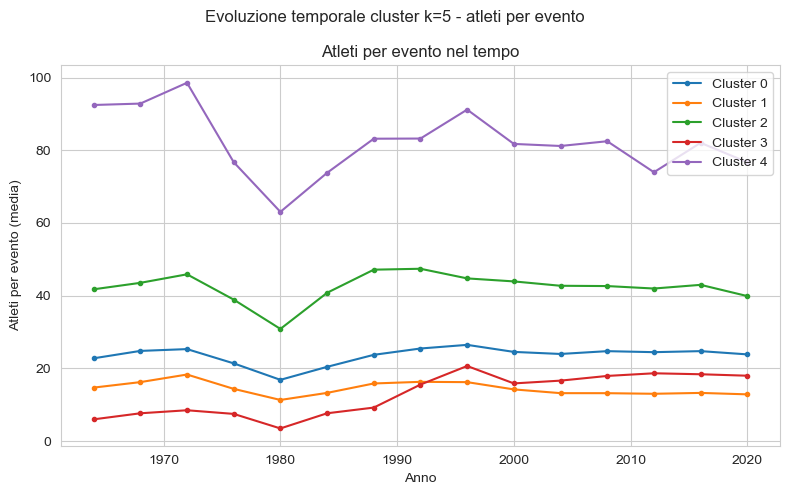

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for c in sorted(trend_k5['cluster_k5'].unique()):
    subset = trend_k5[trend_k5['cluster_k5'] == c]
    ax.plot(subset['year'], subset['n_athletes'], marker='.', label=f'Cluster {c}')

ax.set_title('Atleti per evento nel tempo')
ax.set_xlabel('Anno')
ax.set_ylabel('Atleti per evento (media)')
ax.legend()
ax.grid(True)

plt.suptitle('Evoluzione temporale cluster k=5 - atleti per evento')
plt.tight_layout()
plt.show()

Nazioni partecipanti:

Cluster 4 (grandi eventi globali): parte già alto a ~32 e cresce fino a ~48. Sono gli eventi più seguiti e attraggono sempre più nazioni
Cluster 2 (eventi individuali globali): stabile intorno a 28-32, crescita moderata.
Cluster 0 (nicchia) e Cluster 1 (squadra): stabili e bassi.
Cluster 3 (sport di nicchia): bassissimo e piatto, meno di 20 nazioni sempre.

Nazioni con ori:

Cluster 3: andamento anomalo e instabile, scende quasi a 0 nel 1984 e nel 1988. Questo è molto probabilmente l'effetto dei boicottaggi — Baseball, Badminton e Taekwondo erano sport con pochissime nazioni dominanti, e quando alcune di queste non partecipavano il numero crollava
Tutti gli altri cluster sono stabili intorno a 1: per ogni evento c'è solo una nazione che vince l'oro...

Atleti per evento:
Cluster 4 altissimo e stabile (~80-95): gli eventi iconici attirano moltissimi atleti
Cluster 2 stabile (~40-45)
Cluster 0 ~22-25, Cluster 1 ~13-15, Cluster 3 bassissimo ~7-20